In [2]:
# Install missing dependencies
%pip install scikit-learn pandas numpy matplotlib seaborn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.7 MB 4.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.7 MB 5.0 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.7 MB 5.0 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.7 MB 4.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.7 MB 4.5 MB/s eta 0:00:01
   -


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.1.2-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.80.0-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
  Using


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [5]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url,sep=r"\s+",skiprows=22,header=None)
X = np.hstack([
    raw_df.values[::2, :],
    raw_df.values[1::2, :2]
])
y = raw_df.values[1::2, 2]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (506, 13)
Target Shape  : (506,)


In [6]:
raw_df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8


In [7]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (404, 13)
Testing Data Shape  : (102, 13)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (404, 13)
Testing Data Shape  : (102, 13)


In [9]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Data Scaling Completed")

Data Scaling Completed


In [10]:
model = Sequential([ Dense(64, activation='relu',input_shape=(13,) ),Dense(32,activation='relu'), Dense(1)])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

model.summary()

c:\Users\Ananth Goyal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
print("Training model... please wait.")

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    verbose=0
)

print("Training Completed")

Training model... please wait.
Training Completed


In [12]:
y_pred = model.predict(X_test).flatten()

print("Prediction Completed")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Prediction Completed


In [13]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Difference (Error)': y_test - y_pred
})
# Absolute Error
comparison_df['Absolute Error'] = np.abs(
    comparison_df['Difference (Error)']
)
print("\nTop 10 Test Set Comparisons")
print(
    comparison_df
    .head(10)
    .round(2)
    .to_string(index=False)
)


Top 10 Test Set Comparisons
 Actual Value  Predicted Value  Difference (Error)  Absolute Error
         23.6        28.820000               -5.22            5.22
         32.4        33.209999               -0.81            0.81
         13.6        21.850000               -8.25            8.25
         22.8        27.940001               -5.14            5.14
         16.1        17.100000               -1.00            1.00
         20.0        20.690001               -0.69            0.69
         17.8        14.440000                3.36            3.36
         14.0        14.610000               -0.61            0.61
         19.6        23.559999               -3.96            3.96
         16.8        16.070000                0.73            0.73


In [14]:
new_data_raw = np.array([[0.1, 10.0,
5.0, 0, 0.4, 6.0, 50, 6.0, 1, 400, 20, 300, 10]])
new_data_scaled = scaler.transform(
    new_data_raw
)
# Predict
prediction = model.predict(
    new_data_scaled
)
print("\nPredicted House Price:")
print(f"{prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Predicted House Price:
16.99


<Axes: >

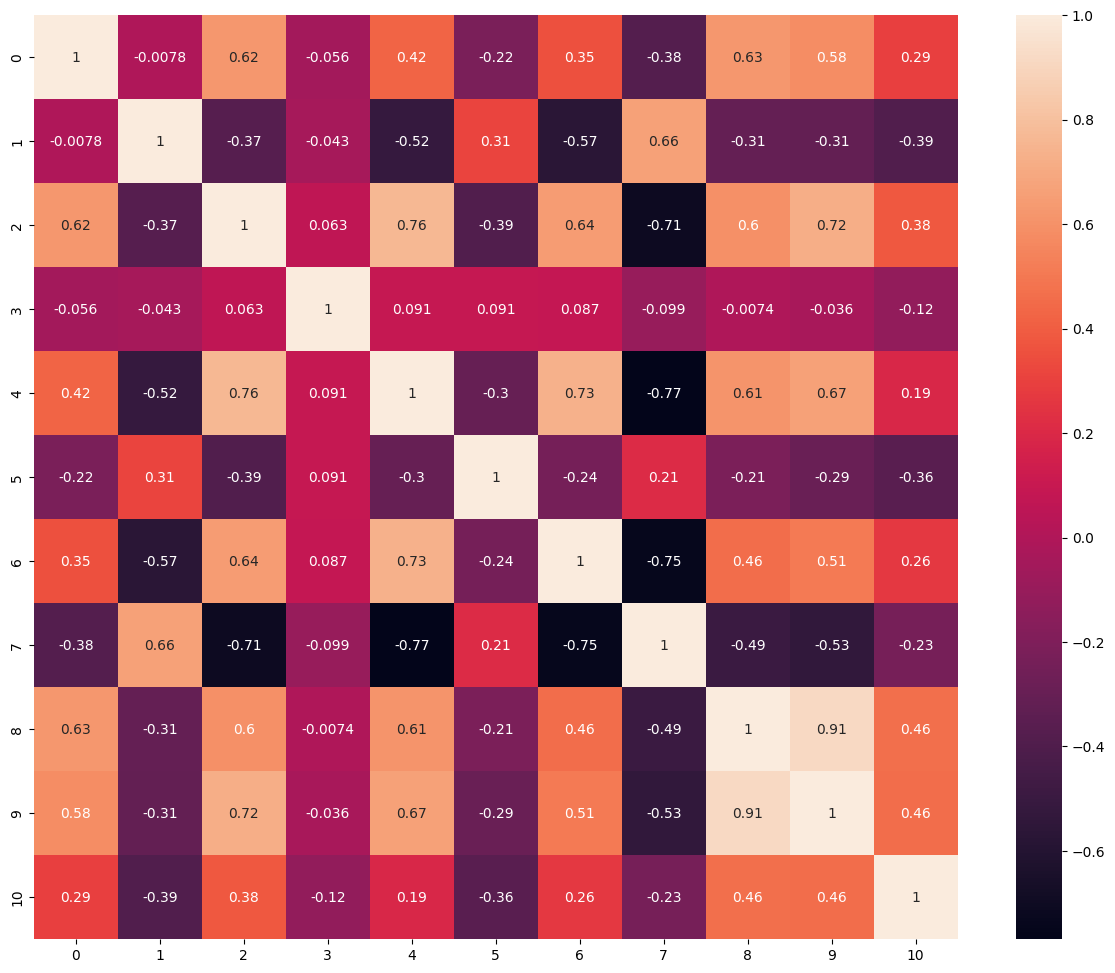

In [15]:
import matplotlib.pyplot as plt
correlation = raw_df.corr()
# correlation.loc['PRICE']

fig,axes = plt.subplots(figsize=(15,12))
sns.heatmap(correlation,square = True,annot = True)

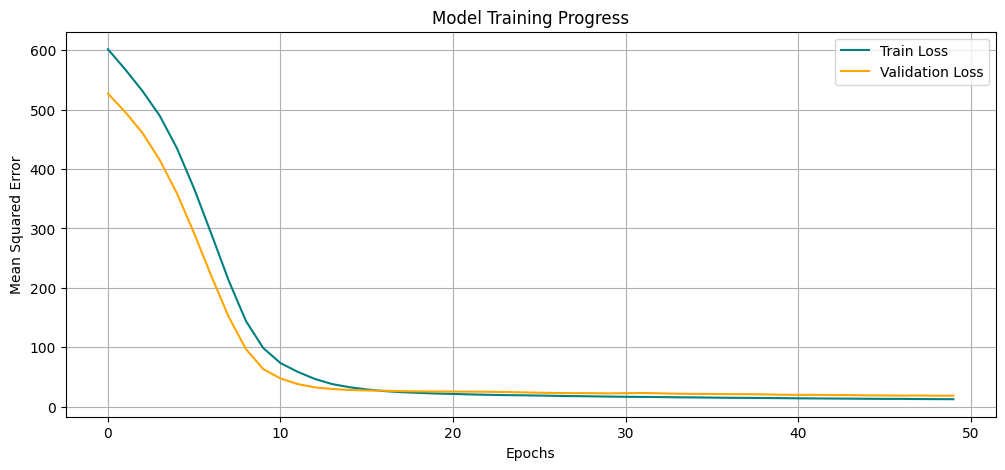

In [16]:
plt.figure(figsize=(12,5))
# Training Loss
plt.subplot(1,1,1)
plt.plot(
    history.history['loss'],
    label='Train Loss',
    color='teal'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    color='orange'
)
plt.title('Model Training Progress')
plt.xlabel('Epochs')

plt.ylabel('Mean Squared Error')

plt.legend()

plt.grid(True)


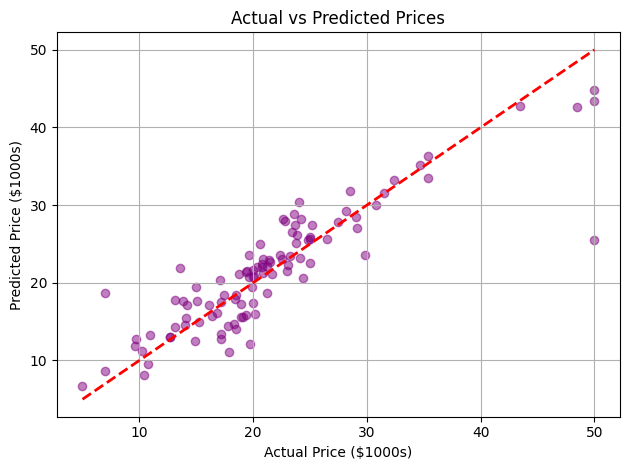

In [17]:

# Actual vs Predicted Scatter Plot

plt.subplot(1,1,1)

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='purple'
)

# Perfect prediction line

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)

plt.title('Actual vs Predicted Prices')

plt.xlabel('Actual Price ($1000s)')

plt.ylabel('Predicted Price ($1000s)')

plt.grid(True)

plt.tight_layout()

plt.show()

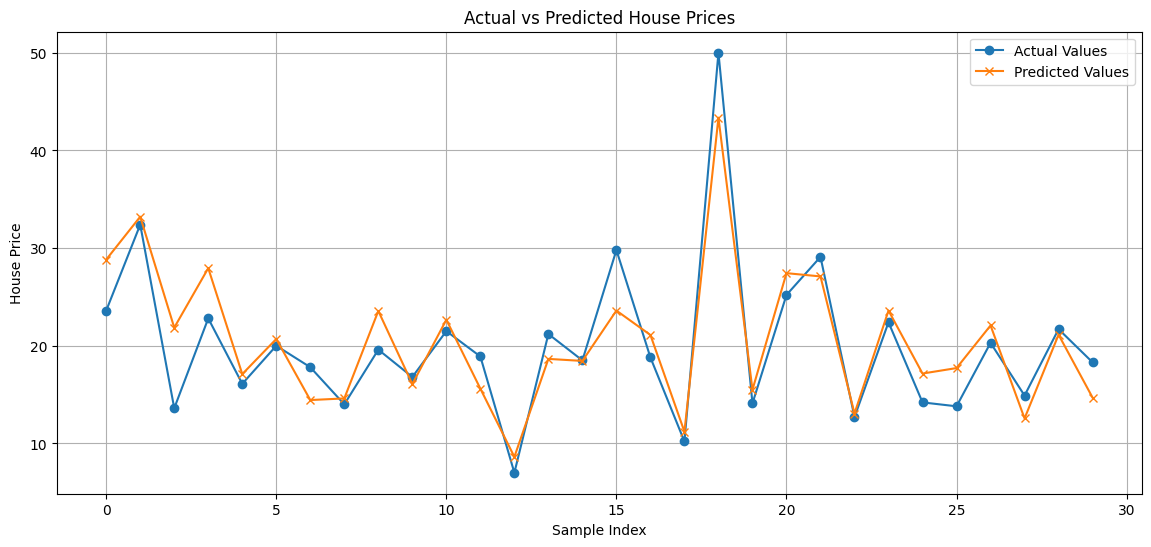

In [18]:
plt.figure(figsize=(14,6))

# Actual Values

plt.plot(
    y_test[:30],
    label='Actual Values',
    marker='o'
)

# Predicted Values

plt.plot(
    y_pred[:30],
    label='Predicted Values',
    marker='x'
)

plt.title("Actual vs Predicted House Prices")

plt.xlabel("Sample Index")

plt.ylabel("House Price")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
# Calculate evaluation metrics

test_mse = mean_squared_error(
    y_test,
    y_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_pred
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    y_pred
)

print("\nModel Evaluation Metrics")

print(f"Mean Squared Error     : {test_mse:.2f}")

print(f"Mean Absolute Error    : {test_mae:.2f}")

print(f"Root Mean Squared Error: {test_rmse:.2f}")

print(f"R2 Score               : {test_r2:.2f}")


Model Evaluation Metrics
Mean Squared Error     : 15.97
Mean Absolute Error    : 2.64
Root Mean Squared Error: 4.00
R2 Score               : 0.78


In [ ]:
'''
1. Aim
To build and train a Deep Neural Network (DNN) using TensorFlow/Keras to predict the house prices in Boston based on various socio-economic features using the Boston Housing dataset.

2. Theory
What is Regression? Regression is a type of supervised machine learning where the goal is to predict a continuous numerical output (target) based on one or more input features. In this assignment, we use regression to predict the median value of homes.

What is a Deep Neural Network (DNN)? A Deep Neural Network is an artificial neural network with multiple hidden layers between the input and output layers. DNNs are powerful at capturing complex, non-linear relationships in data. For regression tasks, the output layer typically has a single neuron with a linear activation function.

Boston Housing Dataset The Boston Housing dataset contains information collected by the U.S. Census Service concerning housing in the area of Boston, Massachusetts. It has 506 samples with 13 input features (like crime rate, number of rooms, property tax, etc.) and 1 target variable (median home value).

Working of DNN for Regression

Input Layer: Receives the 13 features of the Boston dataset.
Hidden Layers (Dense): These layers consist of neurons that use the ReLU activation function to learn the patterns and weights from the data.
Scaling (Standardization): Since features have different ranges (e.g., crime rate vs. tax), we use StandardScaler to ensure all features have a mean of 0 and a variance of 1, which helps the DNN converge faster.
Loss Function (MSE): For regression, we use Mean Squared Error (MSE) to measure how far the predictions are from the actual values.
Optimizer (Adam): The Adam optimizer updates the weights of the network to minimize the loss function during training.
Output Layer: A single neuron that outputs the predicted house price ($1000s).
3. Algorithm
Step 1: Import required libraries: TensorFlow, NumPy, Pandas, Scikit-learn, and Matplotlib.
Step 2: Load the Boston Housing dataset from the StatLib repository.
Step 3: Split the dataset into Training (80%) and Testing (20%) sets.
Step 4: Apply StandardScaler to normalize the feature values.
Step 5: Define the DNN architecture using the Sequential model with multiple Dense layers.
Step 6: Compile the model using the Adam optimizer and MSE loss function.
Step 7: Train the model on the training data for a fixed number of epochs (50).
Step 8: Evaluate the model on the test data using metrics like Mean Absolute Error (MAE) and R2 Score.
Step 9: Plot the Training Loss and Actual vs. Predicted prices to visualize model performance.
4. Conclusion
Thus, we successfully implemented a Deep Neural Network for the Boston House Price Prediction problem. The model was trained and evaluated successfully, and the results demonstrate the effectiveness of DNNs in handling regression-based prediction tasks.
'''